# Churn Predictor — Exploratory Data Analysis

**Project:** Customer churn prediction using XGBoost + SHAP explainability  
**Dataset:** Telco Customer Churn (Kaggle) — 7,043 customers, 21 features  
**Objective:** Identify key drivers of customer churn to support a predictive model targeting AUC-ROC ≥ 0.85  
**Business Impact:** Early churn detection enables targeted retention — reducing revenue loss from high-risk customers  
**Stack:** Python, pandas, seaborn, matplotlib, XGBoost, SHAP, Streamlit

## 1. Imports & Data Load

Load required libraries and read the Telco Churn dataset.
Shape check confirms 7,043 rows and 21 columns.
Null check shows 0 missing values — but TotalCharges nulls are hidden as blank strings, surfaced in Cell 3.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

## 2. Target Variable — Churn Distribution

Check class balance of the target variable (Churn: Yes/No).
- 73.5% No churn (5,174 customers)
- 26.5% Yes churn (1,869 customers)
- Moderate imbalance — requires scale_pos_weight ≈ 2.77 in XGBoost (5174 ÷ 1869)

In [4]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## 3. TotalCharges — Dtype Bug Fix

TotalCharges is stored as string in the raw CSV despite being a numeric field.
Blank strings cause conversion failure — coerced to NaN using pd.to_numeric().
- 11 blank strings found and converted to NaN
- These 11 rows will be handled by median imputation in the preprocessing pipeline
- No rows dropped — 11 out of 7,043 is negligible (0.15%)

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


## 4. Numeric Features vs Churn

Compare average tenure, MonthlyCharges, and TotalCharges between churned and retained customers.
- Tenure: churners avg 18 months vs 37 for retained — early-stage customers churn most
- MonthlyCharges: churners pay more ($74 vs $61) — price sensitivity signal
- TotalCharges: churners lower ($1,531 vs $2,555) — consequence of shorter tenure, not independent driver

In [6]:
print(df.groupby('Churn')['tenure'].mean())
print(df.groupby('Churn')['MonthlyCharges'].mean())
print(df.groupby('Churn')['TotalCharges'].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64
Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


## 5. Contract Type vs Churn

Churn rate broken down by contract type — strongest categorical predictor in the dataset.
- Month-to-month: 42.7% churn rate — no lock-in, easiest to leave
- One year: 11.3% churn rate
- Two year: 2.8% churn rate — committed customers rarely leave
- Month-to-month customers churn at 15x the rate of two-year contract customers

In [7]:
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).round(3))

Contract        Churn
Month-to-month  No       0.573
                Yes      0.427
One year        No       0.887
                Yes      0.113
Two year        No       0.972
                Yes      0.028
Name: proportion, dtype: float64


## 6. Internet Service vs Churn

Churn rate broken down by internet service type — second strongest categorical predictor.
- Fiber optic: 41.9% churn rate — highest bill, highest risk
- DSL: 19% churn rate
- No internet: 7.4% churn rate — lowest bill, lowest risk
- Fiber optic + month-to-month contract = highest risk customer profile in the dataset

In [8]:
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).round(3))

InternetService  Churn
DSL              No       0.810
                 Yes      0.190
Fiber optic      No       0.581
                 Yes      0.419
No               No       0.926
                 Yes      0.074
Name: proportion, dtype: float64


## 7. Churn Distribution — Bar Chart

Visual confirmation of class imbalance between churned and retained customers.
- 5,174 retained (No) vs 1,869 churned (Yes)
- Imbalance ratio ≈ 2.77 — handled via scale_pos_weight in XGBoost

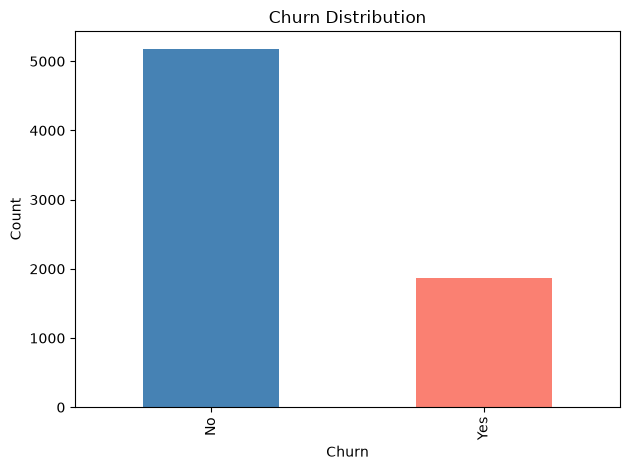

In [9]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 8. Tenure Distribution by Churn

Distribution of customer tenure (months) split by churn label.
- Churn spikes sharply in months 1-3 — highest risk window
- After month 10, churn drops and stays low
- Retained customers cluster heavily at month 72 — long-term customers almost never leave
- Tenure is the strongest numeric predictor of churn

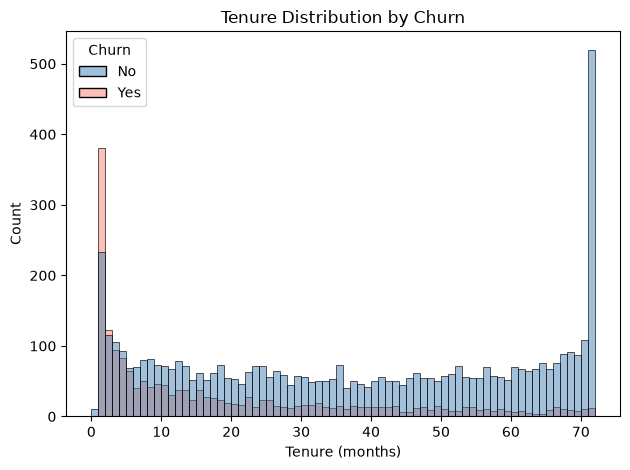

In [10]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=72, palette=['steelblue','salmon'])
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 9. Monthly Charges Distribution by Churn

Distribution of monthly charges split by churn label.
- Low charges ($20-30): almost entirely retained customers
- High charges ($70-120): churn is proportionally much higher
- Expensive plans correlate strongly with churn — likely driven by fiber optic + add-on services
- MonthlyCharges is the second strongest numeric predictor after tenure

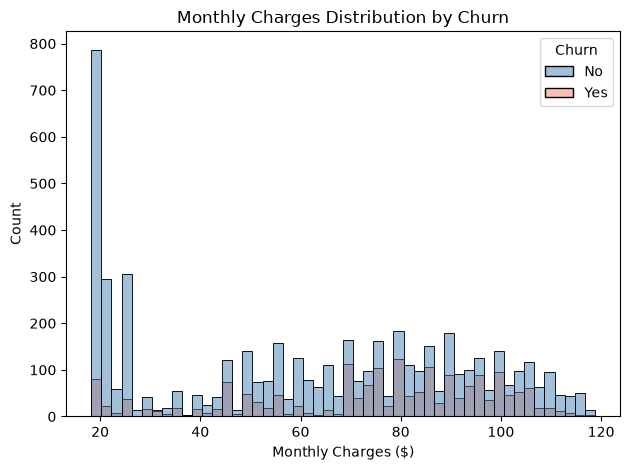

In [11]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=50, palette=['steelblue','salmon'])
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap — Numeric Features

Pairwise correlation between all numeric features and the churn target.
- Tenure → Churn: -0.35 — strongest numeric predictor, longer tenure = less churn
- MonthlyCharges → Churn: +0.19 — higher bill = more churn
- TotalCharges → Churn: -0.20 — largely redundant with tenure (0.83 correlation between them)
- SeniorCitizen → Churn: +0.15 — weak but present
- TotalCharges kept in dataset — XGBoost + SHAP will naturally downweight it

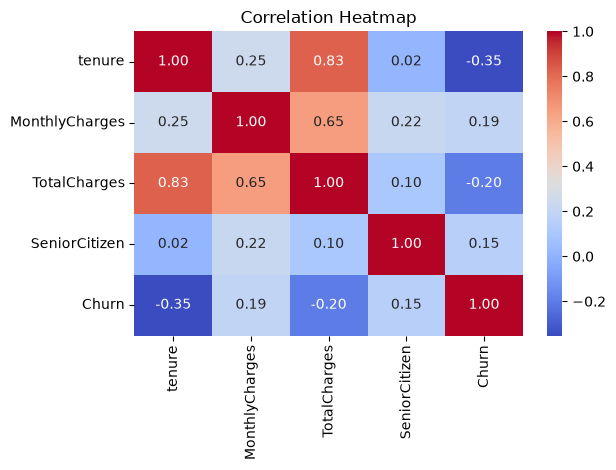

In [12]:
df_corr = df.copy()
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()